# K03_00 – Datenrepräsentation und Vorverarbeitung – Dozentenversion

Update am 27. Mai 2026

Diese Fassung enthält **Musterlösungen und kurze didaktische Hinweise**.

Dieses Notebook ist der **Einstieg in Kapitel 3**.  
Wir schauen uns an, wie tabellarische Daten im Machine Learning dargestellt werden
und warum Vorverarbeitung oft notwendig ist.

## Lernziele
Nach diesem Notebook können Sie:
- zwischen **Samples**, **Features** und **Label** unterscheiden
- numerische und kategoriale Merkmale erkennen
- **fehlende Werte** identifizieren und behandeln
- den **Ordinalen-Kodierungsfehler** bei kategorialen Merkmalen erklären
- **One-Hot-Kodierung** anwenden und am Beispiel von Modellgewichten begründen
- den Unterschied zwischen **nominalen** und **ordinalen** Merkmalen kennen
- den Effekt von **Skalierung** verstehen
- einen vollständig vorverarbeiteten Datensatz in einer **Linearen Regression** verwenden


## 1. Ein kleines Beispieldataset

Wir verwenden einen kleinen fiktiven Datensatz zu Wohnungsangeboten.  
Jede **Zeile** ist ein Sample, jede **Spalte** ein Merkmal (Feature).

Die Zielvariable (Label) heißt hier `preis_in_tsd`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Fiktiver Wohnungsmarkt-Datensatz
# Jede Zeile = eine Wohnung (Sample)
# Spalten = Merkmale (Features) + Zielvariable
df = pd.DataFrame({
    "wohnflaeche": [45, 52, 68, 80, 95, 110, 130, 70],   # numerisch, metrisch
    "zimmer":      [2, 2, 3, 3, 4, 4, 5, 3],              # numerisch, diskret
    "lage":        ["einfach", "mittel", "mittel", "gut",  # kategorial!
                    "gut", "gut", "sehr_gut", "mittel"],
    "baujahr":     [1970, 1985, 1995, 2001, None, 2010, 2018, 1998],  # fehlender Wert!
    "preis_in_tsd": [120, 145, 180, 220, 260, 310, 420, 195]          # Label (Zielvariable)
})

display(df)


,wohnflaeche,zimmer,lage,baujahr,preis_in_tsd
0,45,2,einfach,1970.0,120
1,52,2,mittel,1985.0,145
2,68,3,mittel,1995.0,180
3,80,3,gut,2001.0,220
4,95,4,gut,NaN,260
5,110,4,gut,2010.0,310
6,130,5,sehr_gut,2018.0,420
7,70,3,mittel,1998.0,195


## 2. Merkmalstypen erkennen

Nicht alle Spalten sind gleich. ML-Algorithmen benötigen als Eingabe eine **numerische Matrix** –
aber unsere Rohdaten enthalten verschiedene Typen:

| Spalte | Typ | Erklärung |
|---|---|---|
| `wohnflaeche` | numerisch, metrisch | Subtraktion und Mittelwert sinnvoll |
| `zimmer` | numerisch, diskret | Ganzzahlig, Abstands-Arithmetik sinnvoll |
| `lage` | **kategorial** | Text-Kategorie, kein natürlicher Zahlenwert |
| `baujahr` | numerisch, metrisch | Enthält einen fehlenden Wert (`NaN`) |
| `preis_in_tsd` | numerisch (Label) | Zielvariable für die spätere Regression |

> **Kernproblem:** `lage` ist eine Textspalte. ML-Modelle können nicht mit Strings rechnen.
> Wie kodieren wir das korrekt? Das ist Thema von Abschnitt 4.


In [2]:
# dtype-Übersicht: zeigt uns sofort, welche Spalten Handlungsbedarf haben
print(df.dtypes)
# 'object' bedeutet: Pandas hat diese Spalte als Text gespeichert
# -> 'lage' muss kodiert werden, bevor wir es in ein Modell stecken können


wohnflaeche       int64
zimmer            int64
lage             object
baujahr         float64
preis_in_tsd      int64
dtype: object


## 3. Fehlende Werte erkennen und behandeln

In realen Datensätzen fehlen häufig Werte. Das sehen wir oben bereits bei `baujahr` (Zeile 4).

Die einfachste Strategie: **Imputation** – fehlende Werte durch einen repräsentativen Wert ersetzen.
Häufig verwendete Strategien:
- **Mittelwert** (bei normalverteilten, ausreißer-freien Daten)
- **Median** (robuster gegen Ausreißer)
- **Modus** (häufigster Wert, bei kategorialen Merkmalen)


In [3]:
# Fehlende Werte zählen
print("Fehlende Werte pro Spalte:")
print(df.isnull().sum())


Fehlende Werte pro Spalte:
wohnflaeche     0
zimmer          0
lage            0
baujahr         1
preis_in_tsd    0
dtype: int64


In [4]:
# Imputation: fehlenden Baujahr-Wert durch den Median ersetzen
# Wir verwenden den Median, da er robuster gegen Ausreißer ist als der Mittelwert
df_imputed = df.copy()
median_baujahr = df["baujahr"].median()
df_imputed["baujahr"] = df["baujahr"].fillna(median_baujahr)

print(f"Median Baujahr (zur Imputation): {median_baujahr}")
print()
print("Datensatz nach Imputation (kein NaN mehr):")
display(df_imputed)


Median Baujahr (zur Imputation): 1998.0

Datensatz nach Imputation (kein NaN mehr):


,wohnflaeche,zimmer,lage,baujahr,preis_in_tsd
0,45,2,einfach,1970.0,120
1,52,2,mittel,1985.0,145
2,68,3,mittel,1995.0,180
3,80,3,gut,2001.0,220
4,95,4,gut,1998.0,260
5,110,4,gut,2010.0,310
6,130,5,sehr_gut,2018.0,420
7,70,3,mittel,1998.0,195


### Mini-Übung 1
Warum verwenden wir hier den **Median** statt des Mittelwerts für die Imputation?
Wann wäre der Mittelwert genauso gut oder besser geeignet?


### Musterlösung / Dozentenhinweis
Der **Median** ist robuster gegen Ausreißer. Bei Baujahren könnten sehr alte Gebäude
(z. B. 1890) den Mittelwert stark nach unten ziehen. Der Median bleibt stabil.
Der **Mittelwert** wäre genauso gut, wenn die Verteilung annähernd symmetrisch ist
und keine starken Ausreißer vorliegen.


## 4. Kategoriale Merkmale kodieren

Das Feature `lage` enthält die vier Kategorien:  
`einfach` | `mittel` | `gut` | `sehr_gut`

ML-Algorithmen erwarten eine **numerische Eingabematrix**. Wie wandeln wir Text in Zahlen um?

### Das naive Vorgehen und sein Problem

Die naheliegendste Idee: einfach Ganzzahlen vergeben:

```
einfach → 1,  mittel → 2,  gut → 3,  sehr_gut → 4
```

Das klingt vernünftig – ist aber **methodisch falsch**. Eine Lineare Regression
schätzt für jedes Feature genau **ein Gewicht** `w`. Der Beitrag des Features
zum Ergebnis ergibt sich dann als:

```
Beitrag = w × Featurewert
```

Mit der naiven Kodierung würde das Modell rechnen:

```
einfach:  w × 1 = w
mittel:   w × 2 = 2w
gut:      w × 3 = 3w
sehr_gut: w × 4 = 4w
```

Das Modell kann den Einfluss der Lage nur durch **einen einzigen Faktor** `w` steuern.
Damit wird implizit angenommen:
- Die Lage-Stufen haben **gleich große Abstände** (jede Stufe = +w auf den Preis)
- `sehr_gut` wirkt **viermal so stark** wie `einfach`

Beides ist eine Erfindung des Kodierungsschemas – nicht eine Eigenschaft der Daten.
Dieser Fehler heißt **Ordinaler-Kodierungsfehler** (oder: Label-Encoding-Fehler).


In [5]:
# --- Naiver Ansatz: Label Encoding (INTEGER-Kodierung) ---
# Wir vergeben Ganzzahlen. Das geht schnell, ist aber problematisch!

lage_mapping_naiv = {"einfach": 1, "mittel": 2, "gut": 3, "sehr_gut": 4}
df_naiv = df_imputed.copy()
df_naiv["lage_kodiert"] = df_naiv["lage"].map(lage_mapping_naiv)

print("Naive Kodierung (Label Encoding):")
print(df_naiv[["lage", "lage_kodiert"]].drop_duplicates().sort_values("lage_kodiert"))
print()

# Das Modell lernt EIN Gewicht w fuer die ganze Lage-Spalte.
# Wenn w = 50 (tsd Euro pro Lage-Stufe), ergibt sich:
w_beispiel = 50
print(f"Wenn das Modell w = {w_beispiel} lernt (ein einziges Gewicht fuer 'lage'):")
for kat, code in lage_mapping_naiv.items():
    print(f"  {kat:10s} -> w x {code} = {w_beispiel} x {code} = {w_beispiel * code} (Beitrag zum Preis)")
print()
print("Problem: Die Abstaende einfach->mittel, mittel->gut, gut->sehr_gut")
print("         sind alle exakt gleich gross (je +50). Das Modell hat keine")
print("         Moeglichkeit, das anders zu lernen.")


Naive Kodierung (Label Encoding):
       lage  lage_kodiert
0   einfach             1
1    mittel             2
3       gut             3
6  sehr_gut             4

Wenn das Modell w = 50 lernt (ein einziges Gewicht fuer 'lage'):
  einfach    -> w x 1 = 50 x 1 = 50 (Beitrag zum Preis)
  mittel     -> w x 2 = 50 x 2 = 100 (Beitrag zum Preis)
  gut        -> w x 3 = 50 x 3 = 150 (Beitrag zum Preis)
  sehr_gut   -> w x 4 = 50 x 4 = 200 (Beitrag zum Preis)

Problem: Die Abstaende einfach->mittel, mittel->gut, gut->sehr_gut
         sind alle exakt gleich gross (je +50). Das Modell hat keine
         Moeglichkeit, das anders zu lernen.


### 4.1 Die Lösung: One-Hot-Kodierung

**Idee:** Statt einer Zahlenspalte erstellen wir **eine Binärspalte pro Kategorie**.
Jede Wohnung hat genau eine `1` (in der passenden Spalte) und sonst nur `0`.

| lage | lage_einfach | lage_mittel | lage_gut | lage_sehr_gut |
|---|---|---|---|---|
| einfach  | 1 | 0 | 0 | 0 |
| mittel   | 0 | 1 | 0 | 0 |
| gut      | 0 | 0 | 1 | 0 |
| sehr_gut | 0 | 0 | 0 | 1 |

**Warum funktioniert das?**

Jede neue Spalte bekommt im Modell ihr **eigenes, unabhängiges Gewicht**:

```
einfach:  w_einfach  × 1  +  w_mittel × 0  +  w_gut × 0  +  w_sehr_gut × 0
mittel:   w_einfach  × 0  +  w_mittel × 1  +  w_gut × 0  +  w_sehr_gut × 0
gut:      w_einfach  × 0  +  w_mittel × 0  +  w_gut × 1  +  w_sehr_gut × 0
sehr_gut: w_einfach  × 0  +  w_mittel × 0  +  w_gut × 0  +  w_sehr_gut × 1
```

Die 0/1-Werte wirken hier als **Ein/Aus-Schalter**: Genau das Gewicht der
tatsächlichen Kategorie wird aktiviert, alle anderen werden mit 0 multipliziert
und verschwinden. Das Modell kann so für jede Lage einen **völlig freien,
unabhängigen Preiseinfluss** lernen – ohne erzwungene Abstände.

Das werden wir in Abschnitt 7 konkret sehen, wenn das Modell die Gewichte
tatsächlich schätzt.


In [6]:
# One-Hot-Kodierung mit pd.get_dummies()
# prefix='lage' sorgt fuer lesbare Spaltennamen wie 'lage_gut'
df_encoded = pd.get_dummies(df_imputed, columns=["lage"], prefix="lage")

print("Datensatz nach One-Hot-Kodierung:")
print("(aus 1 Textspalte wurden 4 unabhaengige Binaerspalten)")
print()
display(df_encoded)
print()

# Zeige, wie die Schalter-Logik konkret aussieht:
print("Beispiel fuer 'gut': Nur lage_gut=1, alle anderen=0")
print("-> Im Modell wird nur w_gut aktiviert, alle anderen Lage-Gewichte = 0")


Datensatz nach One-Hot-Kodierung:
(aus 1 Textspalte wurden 4 unabhaengige Binaerspalten)



,wohnflaeche,zimmer,baujahr,preis_in_tsd,lage_einfach,lage_gut,lage_mittel,lage_sehr_gut
0,45,2,1970.0,120,True,False,False,False
1,52,2,1985.0,145,False,False,True,False
2,68,3,1995.0,180,False,False,True,False
3,80,3,2001.0,220,False,True,False,False
4,95,4,1998.0,260,False,True,False,False
5,110,4,2010.0,310,False,True,False,False
6,130,5,2018.0,420,False,False,False,True
7,70,3,1998.0,195,False,False,True,False



Beispiel fuer 'gut': Nur lage_gut=1, alle anderen=0
-> Im Modell wird nur w_gut aktiviert, alle anderen Lage-Gewichte = 0


### 4.2 Ordinal vs. Nominal – wann ist One-Hot die richtige Wahl?

| Merkmals-Typ | Bedeutung | Beispiel | Empfohlene Kodierung |
|---|---|---|---|
| **Nominal** | Kategorien ohne Reihenfolge | Farbe, Stadt, Tierart | **One-Hot-Encoding** |
| **Ordinal** | Kategorien mit natürlicher Reihenfolge | Schulnoten, S/M/L/XL | **OrdinalEncoder** mit definierter Reihenfolge |

**Ist `lage` ordinal oder nominal?**  
`lage` hat zwar eine Reihenfolge (`einfach < mittel < gut < sehr_gut`),
aber die **Abstände** zwischen den Stufen sind inhaltlich unklar.
Ist der Preissprung von `mittel` auf `gut` genauso groß wie von `gut` auf `sehr_gut`?
Das wissen wir nicht – und das Modell soll es selbst lernen dürfen.
Deshalb ist **One-Hot hier die sicherere Wahl**.

### 4.3 Hinweis: die Dummy-Variable-Falle (für Fortgeschrittene)

Bei **linearen Modellen** entsteht ein zusätzliches Problem:
Die 4 One-Hot-Spalten sind **linear abhängig** – ihre Summe ist immer genau 1.
Das führt zu **Multikollinearität**.

Lösung: `drop_first=True` – eine Spalte wird als **Referenzkategorie** weggelassen.
Das Modell liest dann: „Wenn alle anderen 0 sind, ist es die Referenzkategorie.“

Für Entscheidungsbäume und neuronale Netze ist `drop_first` **nicht nötig**.


In [7]:
# drop_first=True: eine Kategorie wird als Referenz weggelassen
# -> 4 Kategorien ergeben dann nur 3 Spalten
# -> empfohlen bei linearen Modellen (Lineare Regression, Logistische Regression)
df_encoded_drop = pd.get_dummies(df_imputed, columns=["lage"], prefix="lage", drop_first=True)

print("One-Hot-Kodierung MIT drop_first=True:")
print("(lage_einfach entfaellt als Referenzkategorie)")
print()
display(df_encoded_drop)
print()
print("Interpretation: lage_mittel=0, lage_gut=0, lage_sehr_gut=0")
print("                --> das Modell weiss: es ist 'einfach' (Referenz).")


One-Hot-Kodierung MIT drop_first=True:
(lage_einfach entfaellt als Referenzkategorie)



,wohnflaeche,zimmer,baujahr,preis_in_tsd,lage_gut,lage_mittel,lage_sehr_gut
0,45,2,1970.0,120,False,False,False
1,52,2,1985.0,145,False,True,False
2,68,3,1995.0,180,False,True,False
3,80,3,2001.0,220,True,False,False
4,95,4,1998.0,260,True,False,False
5,110,4,2010.0,310,True,False,False
6,130,5,2018.0,420,False,False,True
7,70,3,1998.0,195,False,True,False



Interpretation: lage_mittel=0, lage_gut=0, lage_sehr_gut=0
                --> das Modell weiss: es ist 'einfach' (Referenz).


### Mini-Übung 2

1. Warum ist Label-Encoding für `lage` problematisch? Erklären Sie es anhand
   des **einen Gewichts**, das das Modell schätzen müsste.
2. Was ist der Unterschied zwischen einem **nominalen** und einem **ordinalen** Merkmal?
   Geben Sie je ein Beispiel aus dem Alltag.
3. Wann sollte man `drop_first=True` verwenden – und wann nicht?


### Musterlösung / Dozentenhinweis

1. Bei Label-Encoding lernt das Modell **ein einziges Gewicht** `w` für die gesamte
   Lage-Spalte. Damit sind alle Abstände zwischen Kategorien zwangsläufig
   gleich groß (`w`). One-Hot gibt jeder Kategorie ein eigenes Gewicht, das
   vollkommen frei und unabhängig geschätzt werden kann.

2. **Nominal:** Kategorien ohne sinnvolle Reihenfolge (Farbe: Rot/Grün/Blau;
   Stadtname). **Ordinal:** Kategorien mit natürlicher Reihenfolge
   (Schulnoten 1–6; Kleidergröße S/M/L/XL).

3. `drop_first=True` bei **linearen Modellen** (Lineare/Logistische Regression),
   um Multikollinearität zu vermeiden. Bei baumbasierten Modellen und
   neuronalen Netzen ist es **nicht notwendig**.


## 5. Skalierung numerischer Merkmale

Viele ML-Algorithmen sind **skalenabhängig**: Features mit großen Zahlenwerten
(z. B. `baujahr` ~ 1970–2018) dominieren sonst Features mit kleinen Werten
(z. B. `zimmer` 2–5), obwohl beide inhaltlich gleich wichtig sein könnten.

Zwei gängige Verfahren:

| Verfahren | Formel | Ergebnis | Wann verwenden? |
|---|---|---|---|
| **StandardScaler** | `(x − μ) / σ` | Mittelwert=0, Std=1 | Normalverteilte Daten, Ausreißer möglich, SVM / Neuronale Netze |
| **MinMaxScaler** | `(x − min) / (max − min)` | Bereich [0, 1] | Kein Ausreißerproblem, Bildpixelwerte, Sigmoid-Aktivierung |

> **Wichtig:** Skalierung wird **nur auf numerische Spalten** angewendet –
> nicht auf die One-Hot-kodierten Binärspalten (diese sind bereits 0/1).


In [8]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Nur die numerischen Merkmale skalieren
# (One-Hot-Spalten sind bereits 0/1 und brauchen keine weitere Skalierung)
features_numeric = df_imputed[["wohnflaeche", "zimmer", "baujahr"]]

standard_scaler = StandardScaler()
minmax_scaler   = MinMaxScaler()

# fit_transform: lernt Parameter (Mittelwert, Std) und transformiert in einem Schritt
# Achtung: im echten ML-Workflow nur auf Trainingsdaten fitten!
X_standard = pd.DataFrame(
    standard_scaler.fit_transform(features_numeric),
    columns=features_numeric.columns
)

X_minmax = pd.DataFrame(
    minmax_scaler.fit_transform(features_numeric),
    columns=features_numeric.columns
)

print("Originaldaten:")
display(features_numeric.head())

print("Standardisiert (Mittelwert=0, Std=1):")
display(X_standard.head())

print("Min-Max-skaliert (alle Werte in [0, 1]):")
display(X_minmax.head())


Originaldaten:


,wohnflaeche,zimmer,baujahr
0,45,2,1970.0
1,52,2,1985.0
2,68,3,1995.0
3,80,3,2001.0
4,95,4,1998.0


Standardisiert (Mittelwert=0, Std=1):


,wohnflaeche,zimmer,baujahr
0,-1.338753,-1.290994,-1.959491
1,-1.080235,-1.290994,-0.865822
2,-0.489337,-0.258199,-0.136709
3,-0.046164,-0.258199,0.300759
4,0.507803,0.774597,0.082025


Min-Max-skaliert (alle Werte in [0, 1]):


,wohnflaeche,zimmer,baujahr
0,0.000000,0.000000,0.000000
1,0.082353,0.000000,0.312500
2,0.270588,0.333333,0.520833
3,0.411765,0.333333,0.645833
4,0.588235,0.666667,0.583333


### Mini-Übung 3
Prüfen Sie:
1. Welchen Mittelwert hat jede Spalte nach der Standardisierung?
2. In welchem Bereich liegen die Werte nach der Min-Max-Skalierung?


### Musterlösung / Dozentenhinweis

1. Nach der **Standardisierung** hat jede Spalte einen Mittelwert von mathematisch **exakt 0**.
   Kleine Abweichungen wie `1.47e-16` sind **Gleitkomma-Rundungsfehler** des Computers,
   kein Zeichen für Ungenauigkeit des Verfahrens.

2. Nach der **Min-Max-Skalierung** liegen alle Werte garantiert im Bereich **[0, 1]**.

**Wann welches Verfahren?**

**StandardScaler** wenn: Daten annähernd normalverteilt sind, Ausreißer vorhanden sind,
Algorithmen Normalverteilung voraussetzen (Logistische Regression, SVM, Neuronale Netze).

**MinMaxScaler** wenn: Werte garantiert in [0, 1] benötigt werden, keine starken Ausreißer
vorhanden sind, Bilder verarbeitet werden (Pixelwerte 0–255 → 0–1),
Neuronale Netze mit Sigmoid-Aktivierung verwendet werden.


In [9]:
# Numerische Verifikation der Skalierungs-Eigenschaften
print("Mittelwerte nach Standardisierung (mathematisch exakt 0):")
print(X_standard.mean().round(10))
# Hinweis: Werte wie 1.47e-16 sind Gleitkomma-Rundungsfehler, nicht inhaltliche Ungenauigkeit

print("\nStandardabweichungen nach Standardisierung (sollten alle 1.0 sein):")
print(X_standard.std(ddof=0).round(6))  # ddof=0: Populations-Std wie sklearn

print("\nMinima nach Min-Max-Skalierung (sollten alle 0.0 sein):")
print(X_minmax.min().round(6))

print("\nMaxima nach Min-Max-Skalierung (sollten alle 1.0 sein):")
print(X_minmax.max().round(6))


Mittelwerte nach Standardisierung (mathematisch exakt 0):
wohnflaeche    0.0
zimmer         0.0
baujahr        0.0
dtype: float64

Standardabweichungen nach Standardisierung (sollten alle 1.0 sein):
wohnflaeche    1.0
zimmer         1.0
baujahr        1.0
dtype: float64

Minima nach Min-Max-Skalierung (sollten alle 0.0 sein):
wohnflaeche    0.0
zimmer         0.0
baujahr        0.0
dtype: float64

Maxima nach Min-Max-Skalierung (sollten alle 1.0 sein):
wohnflaeche    1.0
zimmer         1.0
baujahr        1.0
dtype: float64


## 6. Zwischenfazit: der vollständig vorverarbeitete Datensatz

Bevor ein ML-Modell trainiert werden kann, müssen alle Eingabe-Features
**numerisch** und **vollständig** (kein NaN) sein – bei vielen Algorithmen
zusätzlich **skaliert**.

Die vollständige Vorverarbeitungs-Pipeline für unseren Datensatz:

| Schritt | Problem | Lösung |
|---|---|---|
| Fehlende Werte | `baujahr` hat NaN | Median-Imputation |
| Kategoriales Feature | `lage` ist Text | One-Hot-Encoding |
| Skalierung | `baujahr` dominiert `zimmer` | StandardScaler |

Im nächsten Abschnitt bauen wir diese Pipeline vollständig auf und
trainieren damit eine **Lineare Regression**.


## 7. Lineare Regression auf dem vorverarbeiteten Datensatz

Jetzt verwenden wir alle Vorverarbeitungsschritte aus den Abschnitten 3–5
und trainieren eine **Lineare Regression**.

Ziel dieses Abschnitts:
- zeigen, wie die vorverarbeiteten Daten als Eingabe in ein Modell fließen
- die **gelernten Gewichte** interpretieren – besonders für die One-Hot-Spalten
- Vorhersagen mit echten Werten vergleichen

> **Hinweis:** Mit nur 8 Samples ist dieses Modell rein illustrativ.
> In der Praxis braucht man deutlich mehr Daten für zuverlässige Schätzungen.
> Das Lernziel hier ist die Verknüpfung von Vorverarbeitung und Modelltraining.


In [10]:
from sklearn.linear_model import LinearRegression

# ── Schritt 1: Vorverarbeitung komplett aufbauen ──────────────────────────

# 1a) Imputation (fehlende Werte)
df_clean = df.copy()
df_clean["baujahr"] = df_clean["baujahr"].fillna(df_clean["baujahr"].median())

# 1b) One-Hot-Encoding fuer 'lage'
#     drop_first=True: Referenzkategorie 'einfach' weglassen (lineare Modelle)
df_clean = pd.get_dummies(df_clean, columns=["lage"], prefix="lage", drop_first=True)

# 1c) Feature-Matrix X und Zielvariable y trennen
feature_cols = ["wohnflaeche", "zimmer", "baujahr",
                "lage_gut", "lage_mittel", "lage_sehr_gut"]
X = df_clean[feature_cols].copy()
y = df_clean["preis_in_tsd"]

# 1d) StandardScaler nur auf numerische Spalten anwenden
num_cols = ["wohnflaeche", "zimmer", "baujahr"]
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])
# One-Hot-Spalten bleiben unveraendert (bereits 0/1)

print("Vollstaendig vorverarbeitete Feature-Matrix X:")
display(X)
print(f"\nForm: {X.shape[0]} Samples, {X.shape[1]} Features")


Vollstaendig vorverarbeitete Feature-Matrix X:


,wohnflaeche,zimmer,baujahr,lage_gut,lage_mittel,lage_sehr_gut
0,-1.338753,-1.290994,-1.959491,False,False,False
1,-1.080235,-1.290994,-0.865822,False,True,False
2,-0.489337,-0.258199,-0.136709,False,True,False
3,-0.046164,-0.258199,0.300759,True,False,False
4,0.507803,0.774597,0.082025,True,False,False
5,1.061770,0.774597,0.956961,True,False,False
6,1.800392,1.807392,1.540251,False,False,True
7,-0.415475,-0.258199,0.082025,False,True,False



Form: 8 Samples, 6 Features


In [16]:
# ── Schritt 2: Modell trainieren ─────────────────────────────────────────

model = LinearRegression()
model.fit(X, y)  # Modell lernt die Gewichte aus den Daten

print("Modell erfolgreich trainiert.")
print(f"Intercept (Basispreis): {model.intercept_:.1f} Tsd. Euro")


Modell erfolgreich trainiert.
Intercept (Basispreis): 225.3 Tsd. Euro


In [12]:
# ── Schritt 3: Gewichte (Koeffizienten) interpretieren ───────────────────

# Jedes Feature hat genau ein Gewicht. Der Wert gibt an:
# 'Um wie viel aendert sich der Preis (in Tsd. Euro), wenn dieses Feature
#  um 1 Einheit steigt (bei skalierten Daten: um 1 Standardabweichung)?'

gewichte = pd.Series(model.coef_, index=feature_cols).sort_values(ascending=False)

print("Gelernte Gewichte (Koeffizienten) der Linearen Regression:")
print()
for feat, w in gewichte.items():
    print(f"  {feat:20s}: {w:+8.1f} Tsd. Euro")

print()
print("Wichtige Beobachtung fuer die One-Hot-Spalten:")
print("  Jede Lage-Kategorie hat ihr EIGENES, unabhaengiges Gewicht.")
print("  Das Modell konnte frei lernen, wie stark sich jede Lage auf")
print("  den Preis auswirkt - ohne erzwungene gleiche Abstaende.")


Gelernte Gewichte (Koeffizienten) der Linearen Regression:

  wohnflaeche         :    +96.7 Tsd. Euro
  lage_sehr_gut       :    +51.4 Tsd. Euro
  lage_mittel         :     +2.2 Tsd. Euro
  baujahr             :     -2.4 Tsd. Euro
  lage_gut            :     -3.6 Tsd. Euro
  zimmer              :    -15.0 Tsd. Euro

Wichtige Beobachtung fuer die One-Hot-Spalten:
  Jede Lage-Kategorie hat ihr EIGENES, unabhaengiges Gewicht.
  Das Modell konnte frei lernen, wie stark sich jede Lage auf
  den Preis auswirkt - ohne erzwungene gleiche Abstaende.


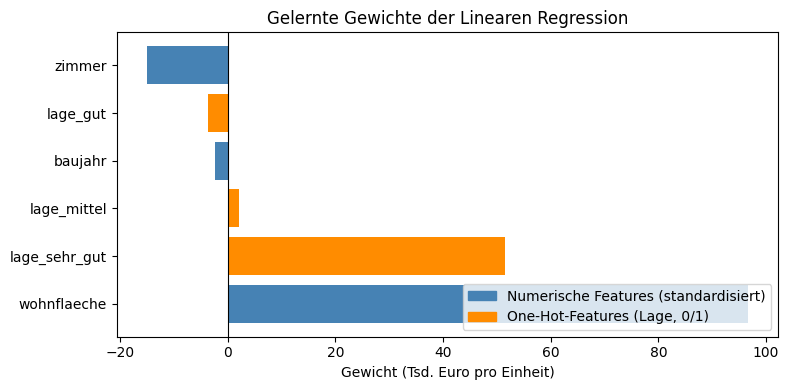

Blau: Einfluss pro Standardabweichung (skaliert)
Orange: Einfluss der jeweiligen Lage-Kategorie gegenueber der
        Referenzkategorie 'einfach' (drop_first=True)


In [13]:
# ── Schritt 4: Visualisierung der Gewichte ────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 4))

farben = ["steelblue" if not f.startswith("lage") else "darkorange"
          for f in gewichte.index]

ax.barh(gewichte.index, gewichte.values, color=farben)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Gewicht (Tsd. Euro pro Einheit)")
ax.set_title("Gelernte Gewichte der Linearen Regression")

# Legende manuell
from matplotlib.patches import Patch
legende = [Patch(color="steelblue", label="Numerische Features (standardisiert)"),
           Patch(color="darkorange", label="One-Hot-Features (Lage, 0/1)")]
ax.legend(handles=legende, loc="lower right")

plt.tight_layout()
plt.show()

print("Blau: Einfluss pro Standardabweichung (skaliert)")
print("Orange: Einfluss der jeweiligen Lage-Kategorie gegenueber der")
print("        Referenzkategorie 'einfach' (drop_first=True)")


In [14]:
# ── Schritt 5: Vorhersagen vs. tatsaechliche Preise ──────────────────────

y_pred = model.predict(X)

ergebnisse = pd.DataFrame({
    "lage":        df["lage"],
    "wohnflaeche": df["wohnflaeche"],
    "preis_tatsaechlich": y.values,
    "preis_vorhersage":   y_pred.round(1),
    "abweichung":         (y_pred - y.values).round(1)
})

print("Vorhersagen vs. tatsaechliche Preise:")
display(ergebnisse)

# R^2: Anteil der erklaerten Varianz (1.0 = perfekte Vorhersage)
r2 = model.score(X, y)
print(f"\nR\u00b2 auf den Trainingsdaten: {r2:.4f}")
print("(Bei 8 Samples und 6 Features ist R\u00b2 ~ 1 erwartet und kein Zeichen")
print(" fuer ein gutes Modell -- das Modell 'memoriert' die Daten.)")


Vorhersagen vs. tatsaechliche Preise:


,lage,wohnflaeche,preis_tatsaechlich,preis_vorhersage,abweichung
0,einfach,45,120,120.0,0.0
1,mittel,52,145,144.5,-0.5
2,mittel,68,180,184.4,4.4
3,gut,80,220,220.5,0.5
4,gut,95,260,259.0,-1.0
5,gut,110,310,310.5,0.5
6,sehr_gut,130,420,420.0,-0.0
7,mittel,70,195,191.0,-4.0



R² auf den Trainingsdaten: 0.9994
(Bei 8 Samples und 6 Features ist R² ~ 1 erwartet und kein Zeichen
 fuer ein gutes Modell -- das Modell 'memoriert' die Daten.)


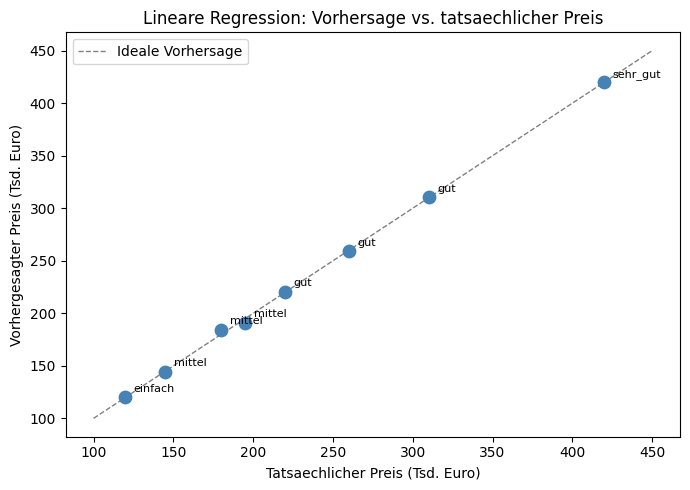

In [15]:
# ── Schritt 6: Vorhersage visualisieren ──────────────────────────────────

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(y, y_pred, color="steelblue", s=80, zorder=3)

# Beschriftung der Punkte mit Lage-Kategorie
for i, (yt, yp, lage) in enumerate(zip(y, y_pred, df["lage"])):
    ax.annotate(lage, (yt, yp), textcoords="offset points",
                xytext=(6, 4), fontsize=8)

# Ideale Linie: Vorhersage = tatsaechlicher Wert
lim = [100, 450]
ax.plot(lim, lim, "--", color="gray", linewidth=1, label="Ideale Vorhersage")

ax.set_xlabel("Tatsaechlicher Preis (Tsd. Euro)")
ax.set_ylabel("Vorhergesagter Preis (Tsd. Euro)")
ax.set_title("Lineare Regression: Vorhersage vs. tatsaechlicher Preis")
ax.legend()
plt.tight_layout()
plt.show()


### Mini-Übung 4

Betrachten Sie die gelernten Gewichte der Lage-Features:

1. Welche Lage hat den größten positiven Einfluss auf den Preis?
2. Warum taucht `lage_einfach` **nicht** in der Gewichtstabelle auf?
3. Was wäre passiert, wenn wir `lage` mit Label-Encoding (1/2/3/4)
   kodiert hätten? Wie viele Lage-Gewichte hätte das Modell dann gelernt?


### Musterlösung / Dozentenhinweis

1. `lage_sehr_gut` hat den größten positiven Einfluss. Das deckt sich mit
   der Erwartung: Top-Lage erhöht den Preis am stärksten.

2. `lage_einfach` wurde mit `drop_first=True` als **Referenzkategorie**
   weggelassen. Alle anderen Lage-Gewichte sind Abweichungen von `einfach`.
   Ein Gewicht von z. B. +120 für `lage_sehr_gut` bedeutet:
   „`sehr_gut`-Lage kostet 120 Tsd. Euro mehr als `einfach`-Lage“.

3. Mit Label-Encoding hätte das Modell **ein einziges Gewicht** für `lage`
   gelernt. Es wäre gezwungen gewesen anzunehmen, dass alle Lage-Stufen
   gleich weit auseinanderliegen – eine Einschränkung, die One-Hot
   vollständig vermeidet.


## 8. Gesamtzusammenfassung

In diesem Notebook haben wir den vollständigen Weg von Rohdaten
bis zum trainierten Modell durchlaufen:

| Schritt | Problem | Lösung |
|---|---|---|
| Merkmalstypen | Text kann kein Modell direkt verarbeiten | Kategoriale Merkmale kodieren |
| Fehlende Werte | NaN führt zu Fehlern | Median-Imputation |
| Label-Encoding | Ein Gewicht erzwingt falsche Abstände | One-Hot-Encoding: ein Gewicht pro Kategorie |
| Skalierung | Große Zahlenwerte dominieren kleine | StandardScaler |
| Modelltraining | Gewichte werden aus Daten gelernt | LinearRegression.fit() |
| Interpretation | Was bedeuten die Gewichte? | Koeffizienten lesen und erklären |

**Kernbotschaft zu One-Hot-Encoding:**  
One-Hot-Kodierung ist nicht wegen der 0/1-Werte an sich besser als Label-Encoding.
Der entscheidende Vorteil ist die **Struktur**: Jede Kategorie erhält ein
eigenes, unabhängiges Gewicht im Modell. Das sehen wir in Abschnitt 7 konkret
an den Koeffizienten der Linearen Regression.
